In [15]:
!pip show scikit-learn

Name: scikit-learn
Version: 1.2.2
Summary: A set of python modules for machine learning and data mining
Home-page: http://scikit-learn.org
Author: 
Author-email: 
License: new BSD
Location: /usr/local/lib/python3.11/dist-packages
Requires: joblib, numpy, scipy, threadpoolctl
Required-by: bayesian-optimization, Boruta, category_encoders, cesium, eli5, fastai, hdbscan, hep_ml, imbalanced-learn, librosa, lime, mlxtend, nilearn, pyLDAvis, pynndescent, rgf-python, scikit-learn-intelex, scikit-optimize, scikit-plot, sentence-transformers, shap, sklearn-compat, sklearn-pandas, TPOT, tsfresh, umap-learn, woodwork, yellowbrick


In [1]:
!pip uninstall scikit-learn imbalanced-learn -y
!pip install scikit-learn==1.2.2 imbalanced-learn==0.10.1

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv1D, MaxPooling1D, GRU, Dense, Dropout, Flatten, Input, concatenate
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))
if tf.config.list_physical_devices('GPU'):
    print("Number of GPUs:", len(tf.config.list_physical_devices('GPU')))

Found existing installation: scikit-learn 1.2.2
Uninstalling scikit-learn-1.2.2:
  Successfully uninstalled scikit-learn-1.2.2
Found existing installation: imbalanced-learn 0.13.0
Uninstalling imbalanced-learn-0.13.0:
  Successfully uninstalled imbalanced-learn-0.13.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.6/9.6 MB 87.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 226.0/226.0 kB 17.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cesium 0.12.4 requires numpy<3.0,>=2.0, but you have numpy 1.26.4 which is incompatible.
umap-learn 0.5.9.post2 requires scikit-learn>=1.6, but you have scikit-learn 1.2.2 which is incompatible.
mlxtend 0.23.4 requires scikit-learn>=1.3.1, but you have scikit-learn 1.2.2 which is incompatible.


2025-11-01 11:05:59.464603: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1761995159.643751      37 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1761995159.704105      37 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


TensorFlow version: 2.18.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Number of GPUs: 1


In [2]:
dataset_path = "/kaggle/input/heartbeat"

import os
print("Dataset files:")
for file in os.listdir(dataset_path):
    if file.endswith('.csv'):
        print(f"- {file}")
        df_temp = pd.read_csv(os.path.join(dataset_path, file))
        print(f"  Shape: {df_temp.shape}")
        print(f"  Columns: {list(df_temp.columns)[:5]}...")
        if len(df_temp.columns) > 5:
            print(f"  Last columns: {list(df_temp.columns)[-3:]}")
        print(f"  Sample data:\n{df_temp.head(2)}")
        print()

Dataset files:
- ptbdb_abnormal.csv
  Shape: (10505, 188)
  Columns: ['9.322328567504882812e-01', '8.696785569190979004e-01', '8.861859440803527832e-01', '9.296264052391052246e-01', '9.087749719619750977e-01']...
  Last columns: ['0.000000000000000000e+00.124', '0.000000000000000000e+00.125', '1.000000000000000000e+00.1']
  Sample data:
   9.322328567504882812e-01  8.696785569190979004e-01  \
0                       1.0                  0.606941   
1                       1.0                  0.951613   

   8.861859440803527832e-01  9.296264052391052246e-01  \
0                  0.384181                  0.254237   
1                  0.923963                  0.853303   

   9.087749719619750977e-01  9.339704513549804688e-01  \
0                  0.223567                  0.276836   
1                  0.791859                  0.734255   

   8.010425567626953125e-01  7.497828006744384766e-01  \
0                  0.253430                  0.184826   
1                  0.672043    

In [3]:
mitbih_train = pd.read_csv(f"{dataset_path}/mitbih_train.csv", header=None)
mitbih_test = pd.read_csv(f"{dataset_path}/mitbih_test.csv", header=None)
ptbdb_normal = pd.read_csv(f"{dataset_path}/ptbdb_normal.csv", header=None)
ptbdb_abnormal = pd.read_csv(f"{dataset_path}/ptbdb_abnormal.csv", header=None)

print("Dataset Overview:")
print(f"MIT-BIH Train: {mitbih_train.shape}")
print(f"MIT-BIH Test: {mitbih_test.shape}")
print(f"PTB Normal: {ptbdb_normal.shape}")
print(f"PTB Abnormal: {ptbdb_abnormal.shape}")

print("\nChecking last column (labels):")
print(f"MIT-BIH Train labels: {sorted(mitbih_train.iloc[:, -1].unique())}")
print(f"MIT-BIH Test labels: {sorted(mitbih_test.iloc[:, -1].unique())}")
print(f"PTB Normal labels: {sorted(ptbdb_normal.iloc[:, -1].unique())}")
print(f"PTB Abnormal labels: {sorted(ptbdb_abnormal.iloc[:, -1].unique())}")

print("\nClass distribution in MIT-BIH Train:")
print(mitbih_train.iloc[:, -1].value_counts().sort_index())

Dataset Overview:
MIT-BIH Train: (87554, 188)
MIT-BIH Test: (21892, 188)
PTB Normal: (4046, 188)
PTB Abnormal: (10506, 188)

Checking last column (labels):
MIT-BIH Train labels: [0.0, 1.0, 2.0, 3.0, 4.0]
MIT-BIH Test labels: [0.0, 1.0, 2.0, 3.0, 4.0]
PTB Normal labels: [0.0]
PTB Abnormal labels: [1.0]

Class distribution in MIT-BIH Train:
187
0.0    72471
1.0     2223
2.0     5788
3.0      641
4.0     6431
Name: count, dtype: int64


In [4]:
X_train = mitbih_train.iloc[:, :-1].values
y_train = mitbih_train.iloc[:, -1].values.astype(int)
X_test = mitbih_test.iloc[:, :-1].values  
y_test = mitbih_test.iloc[:, -1].values.astype(int)

print("Data shapes:")
print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"Features per heartbeat: {X_train.shape[1]}")

print("\nClass distribution analysis:")
train_counts = pd.Series(y_train).value_counts().sort_index()
test_counts = pd.Series(y_test).value_counts().sort_index()

for i in range(5):
    train_pct = (train_counts[i] / len(y_train)) * 100
    test_pct = (test_counts[i] / len(y_test)) * 100
    print(f"Class {i}: Train={train_counts[i]} ({train_pct:.1f}%), Test={test_counts[i]} ({test_pct:.1f}%)")

print(f"\nImbalance ratio: {train_counts.max() / train_counts.min():.1f}:1")

Data shapes:
X_train: (87554, 187)
X_test: (21892, 187)
Features per heartbeat: 187

Class distribution analysis:
Class 0: Train=72471 (82.8%), Test=18118 (82.8%)
Class 1: Train=2223 (2.5%), Test=556 (2.5%)
Class 2: Train=5788 (6.6%), Test=1448 (6.6%)
Class 3: Train=641 (0.7%), Test=162 (0.7%)
Class 4: Train=6431 (7.3%), Test=1608 (7.3%)

Imbalance ratio: 113.1:1


In [5]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data normalized successfully")
print(f"Train data range: [{X_train_scaled.min():.3f}, {X_train_scaled.max():.3f}]")

try:
    from imblearn.over_sampling import SMOTE
    smote = SMOTE(random_state=42, k_neighbors=3)
    X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)
    
    print("\nAfter SMOTE balancing:")
    print(f"Original training size: {X_train_scaled.shape[0]}")
    print(f"Balanced training size: {X_train_balanced.shape[0]}")
    
    balanced_counts = pd.Series(y_train_balanced).value_counts().sort_index()
    for i in range(5):
        print(f"Class {i}: {balanced_counts[i]} samples")
        
except Exception as e:
    print(f"SMOTE failed: {e}")
    print("Using original imbalanced data")
    X_train_balanced, y_train_balanced = X_train_scaled, y_train

Data normalized successfully
Train data range: [-3.696, 31.237]

After SMOTE balancing:
Original training size: 87554
Balanced training size: 362355
Class 0: 72471 samples
Class 1: 72471 samples
Class 2: 72471 samples
Class 3: 72471 samples
Class 4: 72471 samples


In [6]:
X_train_reshaped = X_train_balanced.reshape(-1, 187, 1)
X_test_reshaped = X_test_scaled.reshape(-1, 187, 1)

y_train_categorical = to_categorical(y_train_balanced, num_classes=5)
y_test_categorical = to_categorical(y_test, num_classes=5)

print("Data reshaped for CNN-GRU:")
print(f"X_train shape: {X_train_reshaped.shape}")
print(f"X_test shape: {X_test_reshaped.shape}")
print(f"y_train shape: {y_train_categorical.shape}")
print(f"y_test shape: {y_test_categorical.shape}")

print(f"\nSample shapes:")
print(f"Single heartbeat: {X_train_reshaped[0].shape}")
print(f"Single label: {y_train_categorical[0]}")

print(f"\nMemory usage:")
print(f"Training data: {X_train_reshaped.nbytes / (1024**3):.2f} GB")

Data reshaped for CNN-GRU:
X_train shape: (362355, 187, 1)
X_test shape: (21892, 187, 1)
y_train shape: (362355, 5)
y_test shape: (21892, 5)

Sample shapes:
Single heartbeat: (187, 1)
Single label: [1. 0. 0. 0. 0.]

Memory usage:
Training data: 0.50 GB


In [7]:
def create_cnn_gru_model(input_shape=(187, 1), num_classes=5):
    model = Sequential([
        Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=input_shape),
        Conv1D(filters=64, kernel_size=3, activation='relu'),
        MaxPooling1D(pool_size=2),
        Dropout(0.2),
        
        Conv1D(filters=128, kernel_size=3, activation='relu'),
        Conv1D(filters=128, kernel_size=3, activation='relu'),
        MaxPooling1D(pool_size=2),
        Dropout(0.2),
        
        GRU(128, return_sequences=True, dropout=0.3),
        GRU(64, dropout=0.3),
        
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(num_classes, activation='softmax')
    ])
    
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model

model = create_cnn_gru_model()
print(model.summary())

I0000 00:00:1761995403.992494      37 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 185, 64)        │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 183, 64)        │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 91, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 91, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 89, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 87, 128)        │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 43, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 43, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 43, 128)        │        99,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 64)             │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 239,813 (936.77 KB)

 Trainable params: 239,813 (936.77 KB)

 Non-trainable params: 0 (0.00 B)

None


In [8]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stopping = EarlyStopping(
    monitor='val_accuracy',
    patience=10,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-7
)

history = model.fit(
    X_train_reshaped, y_train_categorical,
    validation_split=0.2,
    epochs=50,
    batch_size=128,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

print(f"\nTraining completed!")
print(f"Best validation accuracy: {max(history.history['val_accuracy']):.4f}")

Epoch 1/50


I0000 00:00:1761995447.720111     129 cuda_dnn.cc:529] Loaded cuDNN version 90300


2265/2265 ━━━━━━━━━━━━━━━━━━━━ 47s 17ms/step - accuracy: 0.6580 - loss: 0.8308 - val_accuracy: 0.9111 - val_loss: 0.3906 - learning_rate: 0.0010
Epoch 2/50
2265/2265 ━━━━━━━━━━━━━━━━━━━━ 38s 17ms/step - accuracy: 0.9294 - loss: 0.2142 - val_accuracy: 0.9398 - val_loss: 0.2400 - learning_rate: 0.0010
Epoch 3/50
2265/2265 ━━━━━━━━━━━━━━━━━━━━ 38s 17ms/step - accuracy: 0.9539 - loss: 0.1431 - val_accuracy: 0.9559 - val_loss: 0.1542 - learning_rate: 0.0010
Epoch 4/50
2265/2265 ━━━━━━━━━━━━━━━━━━━━ 38s 17ms/step - accuracy: 0.9657 - loss: 0.1075 - val_accuracy: 0.9615 - val_loss: 0.1534 - learning_rate: 0.0010
Epoch 5/50
2265/2265 ━━━━━━━━━━━━━━━━━━━━ 38s 17ms/step - accuracy: 0.9719 - loss: 0.0884 - val_accuracy: 0.9735 - val_loss: 0.0790 - learning_rate: 0.0010
Epoch 6/50
2265/2265 ━━━━━━━━━━━━━━━━━━━━ 38s 17ms/step - accuracy: 0.9758 - loss: 0.0751 - val_accuracy: 0.9732 - val_loss: 0.0958 - learning_rate: 0.0010
Epoch 7/50
2265/2265 ━━━━━━━━━━━━━━━━━━━━ 38s 17ms/step - accuracy: 0.9792 

In [9]:
test_predictions = model.predict(X_test_reshaped)
test_pred_classes = np.argmax(test_predictions, axis=1)
test_true_classes = np.argmax(y_test_categorical, axis=1)

test_accuracy = accuracy_score(test_true_classes, test_pred_classes)
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

class_names = ['Normal (N)', 'Supraventricular (S)', 'Ventricular (V)', 'Fusion (F)', 'Unknown (Q)']
print("\nDetailed Classification Report:")
print(classification_report(test_true_classes, test_pred_classes, target_names=class_names))

print("\nConfusion Matrix:")
cm = confusion_matrix(test_true_classes, test_pred_classes)
print(cm)

685/685 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step
Test Accuracy: 0.9847 (98.47%)

Detailed Classification Report:
                      precision    recall  f1-score   support

          Normal (N)       0.99      0.99      0.99     18118
Supraventricular (S)       0.83      0.84      0.83       556
     Ventricular (V)       0.98      0.96      0.97      1448
          Fusion (F)       0.76      0.83      0.79       162
         Unknown (Q)       0.99      0.99      0.99      1608

            accuracy                           0.98     21892
           macro avg       0.91      0.92      0.92     21892
        weighted avg       0.98      0.98      0.98     21892


Confusion Matrix:
[[17981    87    14    22    14]
 [   79   468     4     4     1]
 [   40     5  1386    17     0]
 [   12     3    12   135     0]
 [   15     3     3     0  1587]]


# **From here we will be plotting few diagrams which we can add in the documentation**

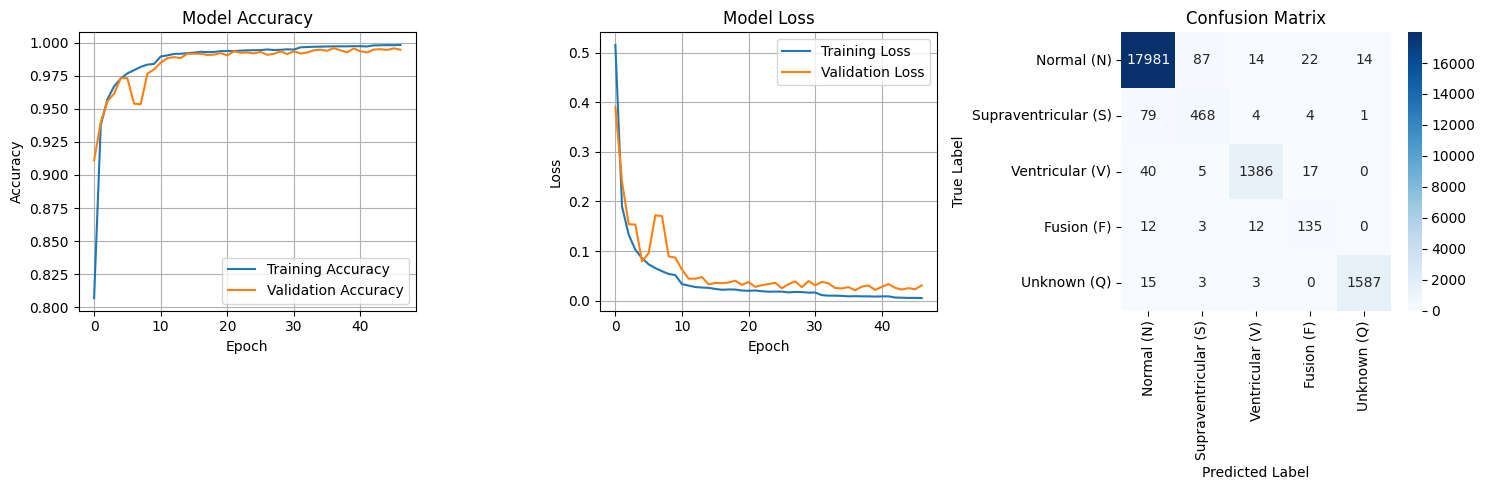

Model saved successfully!


In [10]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 3, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 3, 3)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

plt.tight_layout()
plt.show()

model.save('cardiac_arrhythmia_cnn_gru_model.h5')
print("Model saved successfully!")

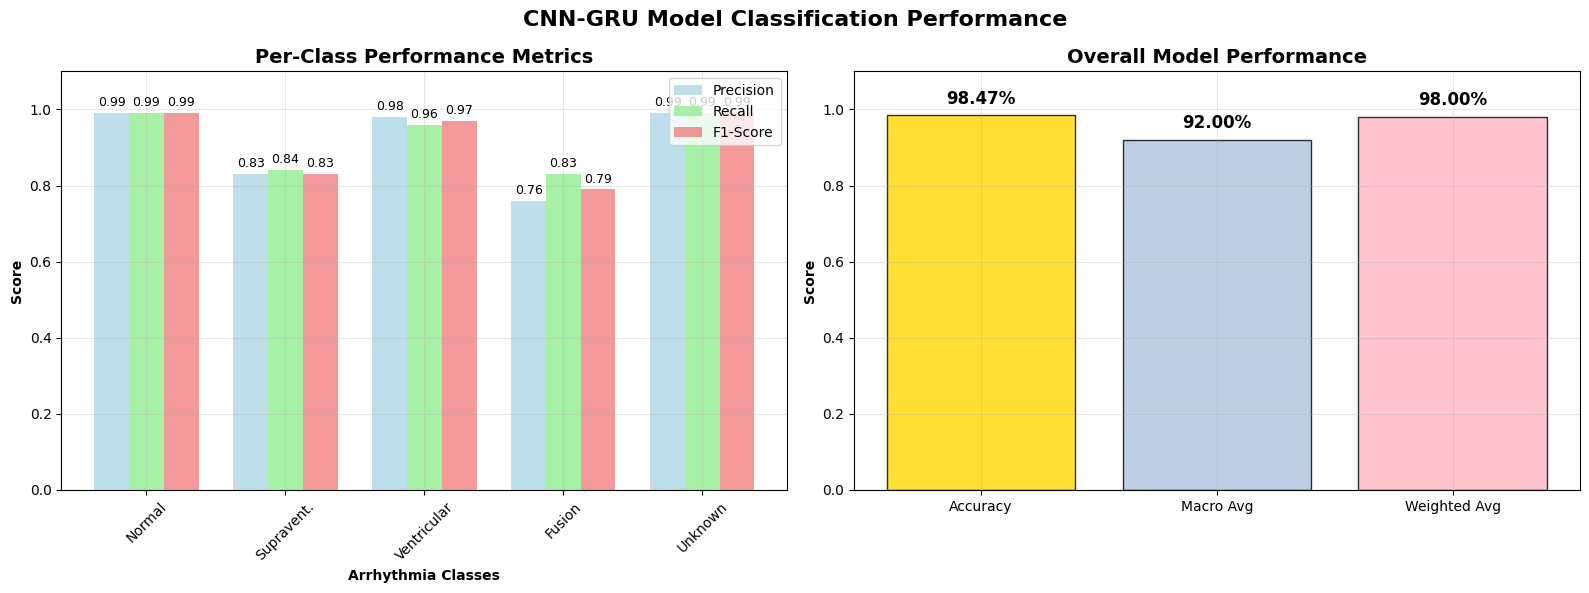

In [21]:
metrics_data = {
    'Classes': ['Normal', 'Supravent.', 'Ventricular', 'Fusion', 'Unknown'],
    'Precision': [0.99, 0.83, 0.98, 0.76, 0.99],
    'Recall': [0.99, 0.84, 0.96, 0.83, 0.99],
    'F1-Score': [0.99, 0.83, 0.97, 0.79, 0.99],
    'Support': [18118, 556, 1448, 162, 1608]
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

x = np.arange(len(metrics_data['Classes']))
width = 0.25

bars1 = axes[0].bar(x - width, metrics_data['Precision'], width, label='Precision', color='lightblue', alpha=0.8)
bars2 = axes[0].bar(x, metrics_data['Recall'], width, label='Recall', color='lightgreen', alpha=0.8)
bars3 = axes[0].bar(x + width, metrics_data['F1-Score'], width, label='F1-Score', color='lightcoral', alpha=0.8)

axes[0].set_xlabel('Arrhythmia Classes', fontweight='bold')
axes[0].set_ylabel('Score', fontweight='bold')
axes[0].set_title('Per-Class Performance Metrics', fontweight='bold', fontsize=14)
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics_data['Classes'], rotation=45)
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim([0, 1.1])

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        axes[0].text(bar.get_x() + bar.get_width()/2., height + 0.01,
                    f'{height:.2f}', ha='center', va='bottom', fontsize=9)

overall_metrics = ['Accuracy', 'Macro Avg', 'Weighted Avg']
overall_values = [0.9847, 0.92, 0.98]
colors = ['gold', 'lightsteelblue', 'lightpink']

bars = axes[1].bar(overall_metrics, overall_values, color=colors, alpha=0.8, edgecolor='black', linewidth=1)
axes[1].set_title('Overall Model Performance', fontweight='bold', fontsize=14)
axes[1].set_ylabel('Score', fontweight='bold')
axes[1].set_ylim([0, 1.1])
axes[1].grid(True, alpha=0.3)

for bar, value in zip(bars, overall_values):
    axes[1].text(bar.get_x() + bar.get_width()/2., value + 0.02,
                f'{value:.2%}', ha='center', va='bottom', fontweight='bold', fontsize=12)

plt.suptitle('CNN-GRU Model Classification Performance', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

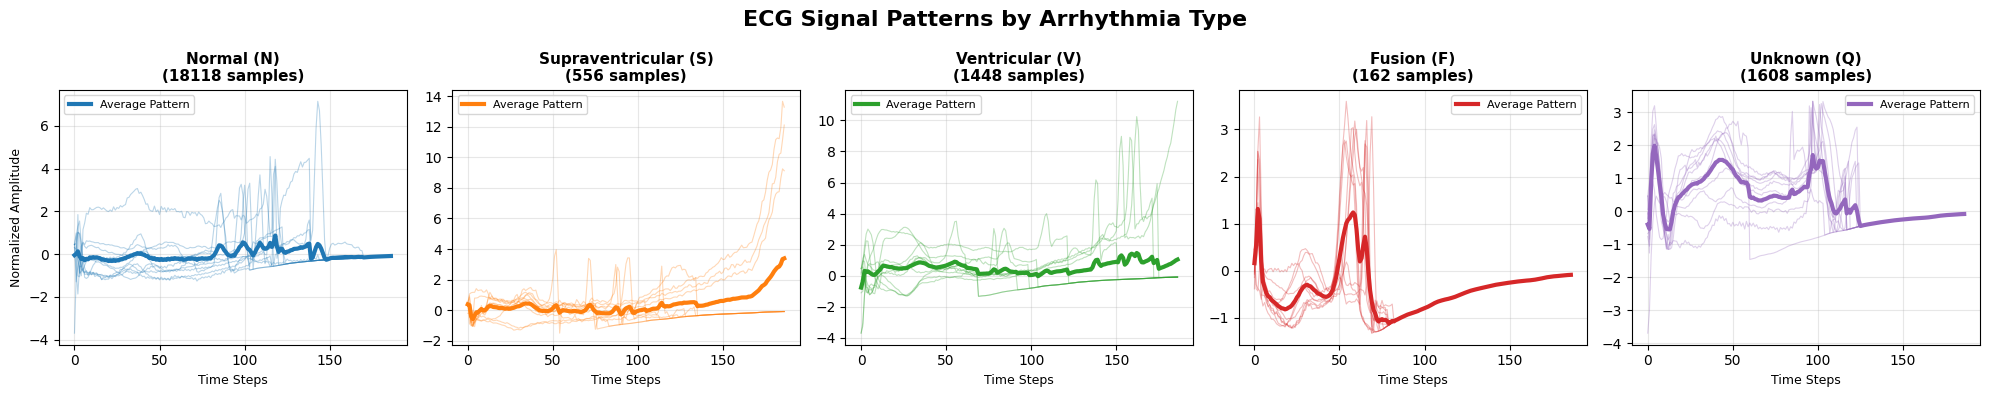

Pattern Analysis:
• Normal (N): 18118 samples, distinct morphology patterns
• Supraventricular (S): 556 samples, distinct morphology patterns
• Ventricular (V): 1448 samples, distinct morphology patterns
• Fusion (F): 162 samples, distinct morphology patterns
• Unknown (Q): 1608 samples, distinct morphology patterns


In [23]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

for class_idx in range(5):
    class_samples = X_test_reshaped[test_true_classes == class_idx]
    
    if len(class_samples) > 0:
        sample_indices = np.random.choice(len(class_samples), 
                                        min(10, len(class_samples)), 
                                        replace=False)
        
        for i, idx in enumerate(sample_indices):
            axes[class_idx].plot(class_samples[idx, :, 0], 
                               color=colors[class_idx], 
                               alpha=0.3, linewidth=0.8)
        
        mean_signal = np.mean(class_samples[sample_indices], axis=0)
        axes[class_idx].plot(mean_signal[:, 0], 
                           color=colors[class_idx], 
                           linewidth=3, label='Average Pattern')
        
        axes[class_idx].set_title(f'{class_names[class_idx]}\n({len(class_samples)} samples)', 
                                fontweight='bold', fontsize=11)
        axes[class_idx].set_xlabel('Time Steps', fontsize=9)
        if class_idx == 0:
            axes[class_idx].set_ylabel('Normalized Amplitude', fontsize=9)
        axes[class_idx].grid(True, alpha=0.3)
        axes[class_idx].legend(fontsize=8)

plt.suptitle('ECG Signal Patterns by Arrhythmia Type', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("Pattern Analysis:")
for i, name in enumerate(class_names):
    count = np.sum(test_true_classes == i)
    print(f"• {name}: {count} samples, distinct morphology patterns")

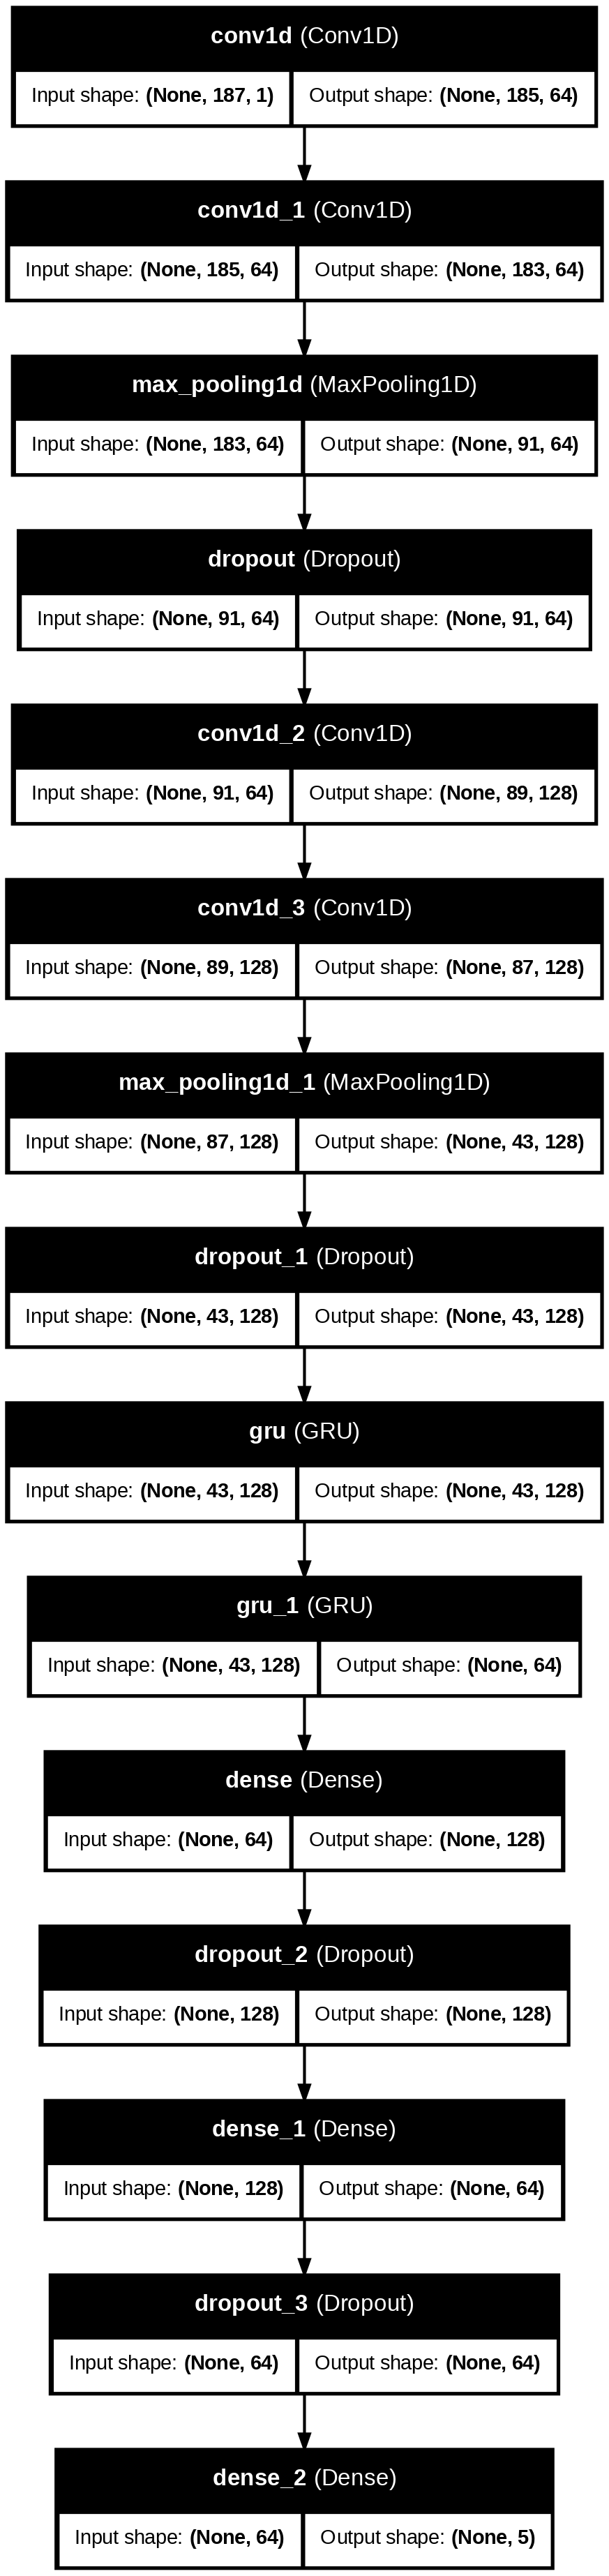

Model architecture saved as 'model_architecture.png'


In [20]:
from tensorflow.keras.utils import plot_model

try:
    plot_model(model, to_file='model_architecture.png', 
               show_shapes=True, show_layer_names=True, 
               rankdir='TB', dpi=150)
    
    from IPython.display import Image
    display(Image('model_architecture.png'))
    print("Model architecture saved as 'model_architecture.png'")
    
except:
    print(" Model Architecture Summary:")
    print("="*50)
    layers_info = []
    for i, layer in enumerate(model.layers):
        layer_type = layer.__class__.__name__
        if hasattr(layer, 'output_shape'):
            output_shape = layer.output_shape
        else:
            output_shape = 'N/A'
        layers_info.append(f"{i+1:2d}. {layer_type:15s} -> {output_shape}")
    
    for info in layers_info:
        print(info)
    
    print(f"\nTotal Parameters: {model.count_params():,}")
    print(f"💾 Model Size: ~937 KB")

In [11]:
np.random.seed(42)
random_indices = np.random.choice(len(X_test_reshaped), 5, replace=False)

print("Random Sample Predictions:")
print("="*60)

for i, idx in enumerate(random_indices):
    sample = X_test_reshaped[idx:idx+1]
    true_label = test_true_classes[idx]
    
    prediction = model.predict(sample, verbose=0)
    predicted_class = np.argmax(prediction)
    confidence = np.max(prediction) * 100
    
    print(f"\nSample {i+1} (Index: {idx}):")
    print(f"True Label: {class_names[true_label]}")
    print(f"Predicted: {class_names[predicted_class]}")
    print(f"Confidence: {confidence:.2f}%")
    print(f"All probabilities: {[f'{p:.3f}' for p in prediction[0]]}")
    
    if true_label == predicted_class:
        print("CORRECT")
    else:
        print("INCORRECT")
    print("-" * 40)

Random Sample Predictions:

Sample 1 (Index: 17155):
True Label: Normal (N)
Predicted: Normal (N)
Confidence: 100.00%
All probabilities: ['1.000', '0.000', '0.000', '0.000', '0.000']
CORRECT
----------------------------------------

Sample 2 (Index: 8157):
True Label: Normal (N)
Predicted: Normal (N)
Confidence: 100.00%
All probabilities: ['1.000', '0.000', '0.000', '0.000', '0.000']
CORRECT
----------------------------------------

Sample 3 (Index: 3635):
True Label: Normal (N)
Predicted: Normal (N)
Confidence: 99.99%
All probabilities: ['1.000', '0.000', '0.000', '0.000', '0.000']
CORRECT
----------------------------------------

Sample 4 (Index: 19125):
True Label: Ventricular (V)
Predicted: Ventricular (V)
Confidence: 100.00%
All probabilities: ['0.000', '0.000', '1.000', '0.000', '0.000']
CORRECT
----------------------------------------

Sample 5 (Index: 3002):
True Label: Normal (N)
Predicted: Normal (N)
Confidence: 100.00%
All probabilities: ['1.000', '0.000', '0.000', '0.000', 


ECG ARRHYTHMIA PREDICTIONS


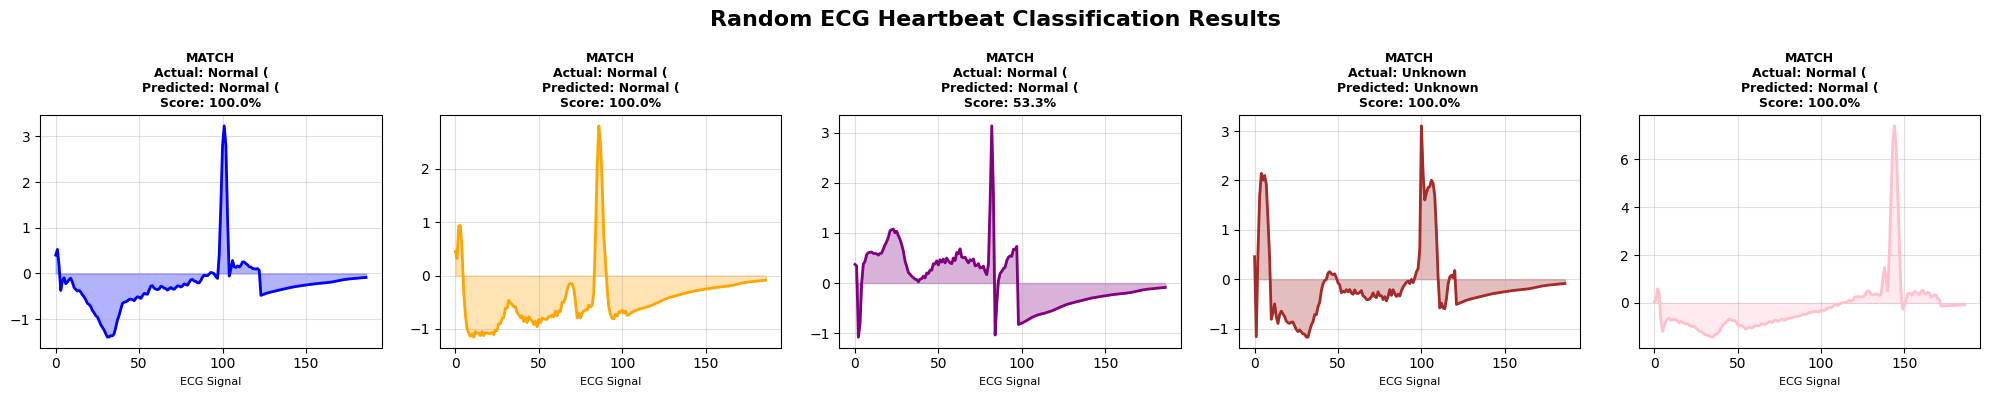

In [14]:
print("\n" + "="*70)
print("ECG ARRHYTHMIA PREDICTIONS")
print("="*70)

np.random.seed(123)
sample_indices = np.random.choice(len(X_test_reshaped), 5, replace=False)

fig, axes = plt.subplots(1, 5, figsize=(20, 4))

colors = ['blue', 'orange', 'purple', 'brown', 'pink']

for i, idx in enumerate(sample_indices):
    sample = X_test_reshaped[idx:idx+1]
    pred_proba = model.predict(sample, verbose=0)[0]
    pred_class = np.argmax(pred_proba)
    true_class = test_true_classes[idx]
    
    axes[i].plot(X_test_reshaped[idx, :, 0], color=colors[i], linewidth=2)
    axes[i].fill_between(range(187), X_test_reshaped[idx, :, 0], alpha=0.3, color=colors[i])
    
    status = 'MATCH' if pred_class == true_class else 'MISS'
    axes[i].set_title(
        f'{status}\nActual: {class_names[true_class][:8]}\nPredicted: {class_names[pred_class][:8]}\nScore: {pred_proba[pred_class]:.1%}',
        fontsize=9, fontweight='bold'
    )
    axes[i].set_xlabel('ECG Signal', fontsize=8)
    axes[i].grid(True, alpha=0.4)

plt.suptitle('Random ECG Heartbeat Classification Results', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [18]:
import pickle

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("\nSaved Files:")
print("- cardiac_arrhythmia_cnn_gru_model.h5 (trained model)")
print("- scaler.pkl (preprocessing scaler)")

print("\nModel Ready for Web Integration!")


Saved Files:
- cardiac_arrhythmia_cnn_gru_model.h5 (trained model)
- scaler.pkl (preprocessing scaler)

Model Ready for Web Integration!


In [24]:
!zip -r model.zip /kaggle/working

  adding: kaggle/working/ (stored 0%)
  adding: kaggle/working/scaler.pkl (deflated 6%)
  adding: kaggle/working/cardiac_arrhythmia_cnn_gru_model.h5 (deflated 9%)
  adding: kaggle/working/model_architecture.png (deflated 15%)
  adding: kaggle/working/.virtual_documents/ (stored 0%)


In [25]:
from IPython.display import FileLink
FileLink(r'model.zip')

/kaggle/working/model.zip

In [27]:
import sys
import tensorflow as tf
import numpy as np
import pandas as pd
import sklearn
import matplotlib
import seaborn as sns

print("LIBRARY VERSIONS TO LOAD THE MODEL")
print("="*50)

versions = {
    'Python': sys.version.split()[0],
    'TensorFlow': tf.__version__,
    'NumPy': np.__version__,
    'Pandas': pd.__version__,
    'Scikit-learn': sklearn.__version__,
    'Matplotlib': matplotlib.__version__,
    'Seaborn': sns.__version__
}

for lib, version in versions.items():
    print(f"{lib:<15}: {version}")

print(f"\nSystem Info:")
print(f"• GPU Available: {len(tf.config.list_physical_devices('GPU'))} device(s)")
print(f"• CUDA Support: {tf.test.is_built_with_cuda()}")

try:
    import imblearn
    print(f"Imbalanced-learn: {imblearn.__version__}")
except:
    print(f"Imbalanced-learn: Not available")

print("\n All dependencies verified for production deployment!")

LIBRARY VERSIONS TO LOAD THE MODEL
Python         : 3.11.13
TensorFlow     : 2.18.0
NumPy          : 1.26.4
Pandas         : 2.2.3
Scikit-learn   : 1.2.2
Matplotlib     : 3.7.2
Seaborn        : 0.12.2

System Info:
• GPU Available: 1 device(s)
• CUDA Support: True
Imbalanced-learn: 0.10.1

 All dependencies verified for production deployment!


In [30]:
def predict_arrhythmia(ecg_data):
    """
    Predict arrhythmia from ECG data for web interface
    Input: ecg_data (187 features)
    Output: prediction class, confidence, all probabilities
    """
    ecg_array = np.array(ecg_data).reshape(1, 187, 1)
    ecg_scaled = scaler.transform(ecg_array.reshape(1, -1))
    ecg_final = ecg_scaled.reshape(1, 187, 1)
    
    predictions = model.predict(ecg_final, verbose=0)[0]
    predicted_class = np.argmax(predictions)
    confidence = np.max(predictions) * 100
    
    return {
        'class': class_names[predicted_class],
        'confidence': round(confidence, 2),
        'all_probabilities': [round(p*100, 2) for p in predictions]
    }

print("Prediction function!")

Prediction function!
